# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 5. Поиск типичных подпоследовательностей временного ряда.**

In [1]:
%load_ext autoreload
%autoreload 2

Импорт библиотек и модулей

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from modules.snippets import *
from scipy import signal
from stumpy import snippets

In [3]:
import os

practice_dir_path = 'C:\\hw\\2025-Simirgeev-TimeSeriesCourse\\practice\\05 Snippets'
os.chdir(practice_dir_path)

### **Задача 1. Поиск сниппетов одномерного временного ряда**

В первой задаче необходимо выполнить поиск сниппетов одномерного временного ряда. Расмотрите приведенный ниже пример использования алгоритма SnipperFinder и визуализации полученных результатов для искуственного врменного ряда.

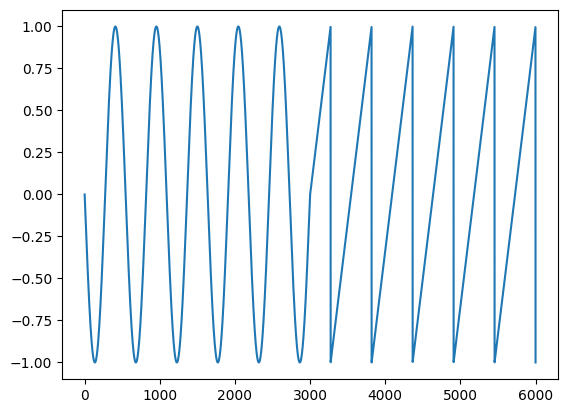

In [4]:
#Создание искусственного временного ряда
t = np.linspace(np.pi, 6 * 2 * np.pi, 3000)
ts = np.concatenate([np.sin(t), signal.sawtooth(t)])
plt.plot(ts)

In [5]:
#Поиск сниппетов
snp = snippets(ts, 600, 2, percentage=0.5)

600


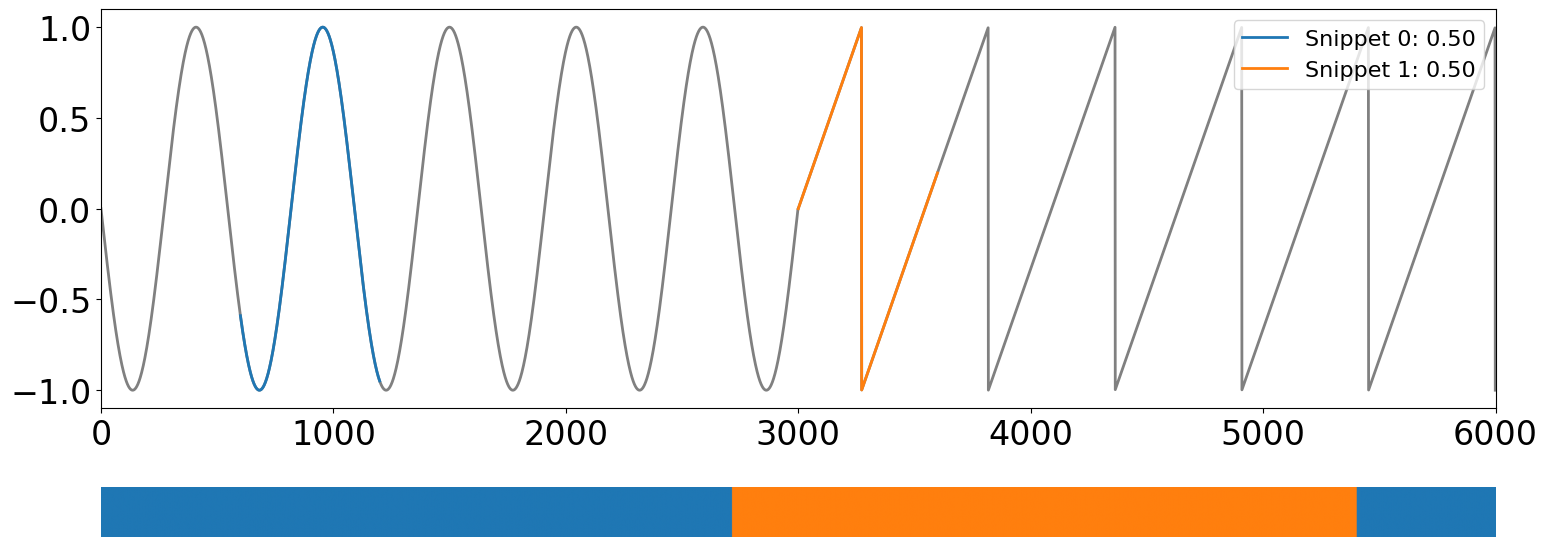

<Axes: >

In [6]:
#Визуализация результатов
plot_snippets(ts, snp)

Далее вам предстоит самостоятельно выполнить поиск top-$k$ типичных подпоследовательностей временного ряда (сниппетов) с помощью алгоритма SnippetFinder на наборе данных PAMAP. Описание набора данных находится в [README-файле](datasets/PAMAP/readme.md).

Выполните считывание временного ряда **показаний гироскопа на оси «Y» (угол тангажа) на временном интервале от 1790 сек. до 1930 сек.** (используя колонку с временными метками) из файла *PAMAP.txt*, который располагается в директории *./datasets/PAMAP*. Затем выполните поиск сниппетов с помощью функции `snippets()` из библиотеки stumpy. Затем визуализируйте полученные результаты, используя функцию `plot_snippets()` из модуля snippets.py.

In [7]:
import pandas as pd

data = pd.read_csv('./datasets/PAMAP/PAMAP.txt', sep=' ', header=None).transpose()
filtered_data = data[data[0].between(1790, 1930)]
snippets_res = snippets(filtered_data[11], 600, 2)

Выполните визулизацию временного ряда и найденных сниппетов с помощью функции `plot_snippets()` из модуля snippets.py.

600


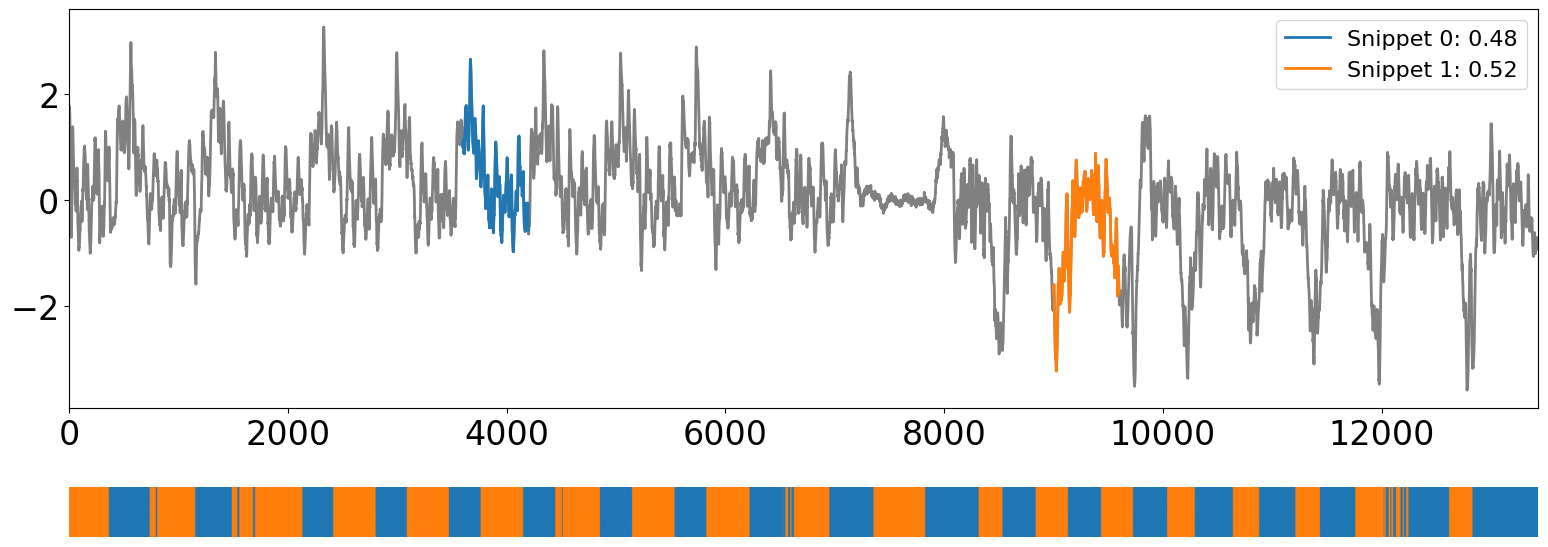

<Axes: >

In [8]:
plot_snippets(np.array(filtered_data[11]), snippets_res)

Оцените точность разметки, полученной при помощи сниппетов, используя исходные данные об активностях в ряде.

[12. 13.]


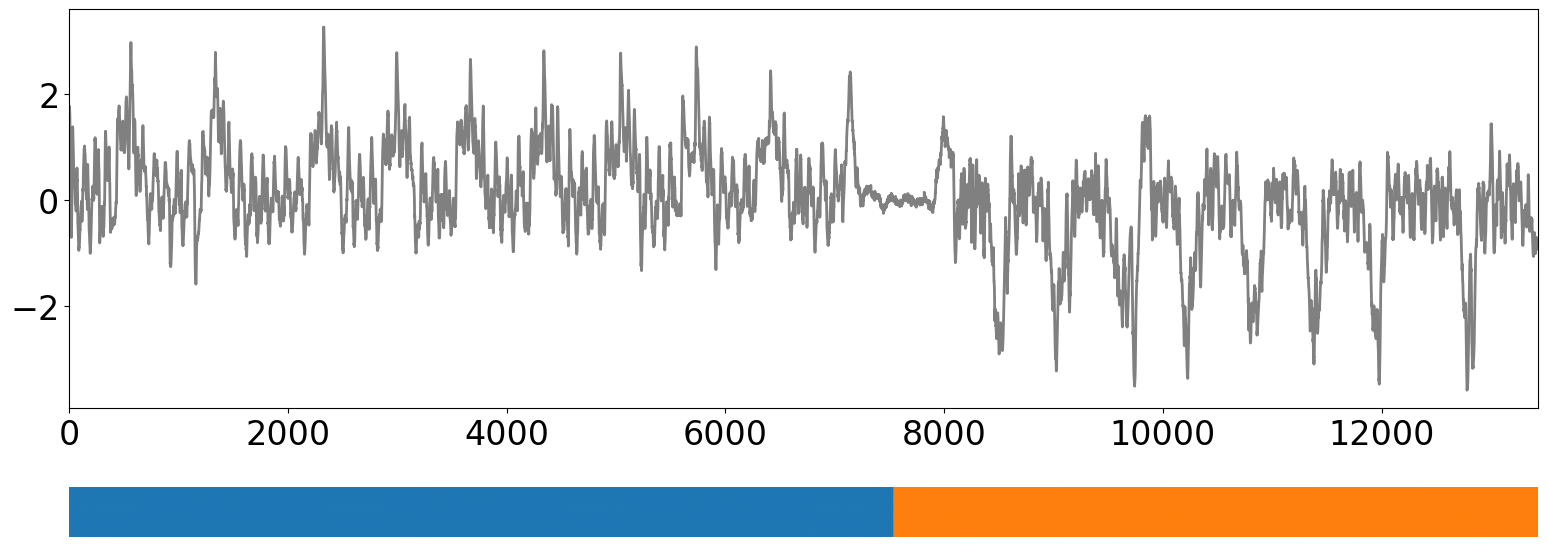

In [9]:
print(filtered_data[1].unique())
# -   12 ascending stairs
# -   13 descending stairs

with plt.rc_context(
        {
            "lines.linewidth": 2,
            "font.size": 24,
        }
    ):
        fig, (ax_main, ax_labels) = plt.subplots(
            2, figsize=(16, 6), gridspec_kw={"height_ratios": [16, 2]}
        )
        color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

        data_plot = np.array(filtered_data[11])
        ax_main.plot(data_plot, color="gray")

        labels = np.zeros_like(data_plot)
        for regime in range(len(filtered_data[1])):
            labels[regime] = 0 if filtered_data[1].iloc[regime] == 12 else 1

        img = ax_labels.imshow([range(len(color_cycle))], cmap="tab10", aspect="auto")
        img.set_data([labels])

        ax_main.set_xlim(0, len(data_plot))
        ax_labels.axis("off")
        plt.tight_layout()
        plt.show()

❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Исходя из первого графика можно заметить, что значения наблюдаемой величины примерно половину времени находится выше нуля, а потом становится ниже нуля. Значит, человек сначала поднимается, потом опускается в пространстве по оси Y. Однако, если по графику эти выводы сделать можно, то по индексам сниппетов - нельзя. Они постоянно меняются, что, в отрыве от графика, может привести к выводу, что человек сначала поднимается, а затем спускается, будто бы на одной и той же ступеньке. По второму графику уже понятно, что в первую половину времени человек поднимается, а вторую - спускается.

### Задача 2. Разметка многомерного временного ряда

Выполните разметку многомерного временно ряда, используя **показания гироскопа по всем трем осям** из набора данных PAMAP. Используйте тот же временной интервал, что и в задаче 1. Итоговую разметку получите в результате голосования большинством.

In [9]:
# INSERT YOUR CODE

Оцените точность разметки многомерного ряда, используя исходные данные об активностях.

In [10]:
# INSERT YOUR CODE

❓ Проанализируйте и изложите содержательный смысл полученных результатов. Сравните полученные разметки многомерного и одномерного рядов.

## Задача 3. Подбор оптимального значения _k_


Разработайте программу, которая выполняет выполняет вычисление меры $change$ для различных значений $k$ с помощью алгоритма SnippetFinder. Проведите эксперименты, используя временной ряд из задания 2 (взяв 1 ≤ _k_ ≤ 9).

$Change_k = \frac{ProfileArea_{k-1}}{ProfileArea_k} - 1$

In [11]:
# INSERT YOUR CODE

Выполните визуализацию результатов экспериментов в следующем виде: отображение столбчатых диаграм со значениями $ProfileArea$ и меры $change$ в зависимости от $k$.

In [12]:
# INSERT YOUR CODE

❓ Проанализируйте и изложите содержательный смысл полученных результатов. Какое значение $k$ является наилучшим для используемого временного ряда?